# Uncertainty-Guaranteed Informative Path Planning

This tutorial will guide you through using Uncertainty-Guaranteed Informative Path Planning (IPP) methods available in the `sgptools` library. There methods aim to place sensors or waypoints such that the uncertainty (variance) over a given environment is reduced below a specific threshold.

We will cover how to initialize the environment, compute ground truth Gaussian Process (GP) parameters, and compare different coverage strategies (`HexCover`, `GreedyCover`, and `GCBCover`) both with and without "warm starts."

## Setup and Imports

We begin by importing the necessary libraries. We'll use `gpflow` and `tensorflow` for the underlying Gaussian Process modeling, and `matplotlib` for visualizing our results.

In [ ]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

from time import time
import numpy as np 
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.pyplot as plt

import tensorflow as tf
import gpflow

# Configure GPflow defaults
gpflow.config.set_default_float(np.float32)
gpflow.config.set_default_jitter(1e-2)

# Import necessary components from sgptools
from sgptools.methods import get_method
from sgptools.kernels import get_kernel
from sgptools.utils.tsp import run_tsp, resample_path
from sgptools.utils.misc import get_inducing_pts
from sgptools.utils.metrics import get_distance, get_mse, get_smse
from sgptools.utils.data import Dataset
from sgptools.utils.gpflow import get_model_params

# Set random seeds for reproducibility
np.random.seed(1234)
tf.random.set_seed(1234)

## Helper Functions
 
To keep our main code clean, we define two helper functions:
1. `get_grid`: Generates a regular 2D grid over our spatial domain for evaluating and plotting predictions.
2. `plot_coverage_results`: Visualizes the GP predictions, variance, and the selected sensor Fields of View.


In [2]:
def get_grid(X_data, num_x, num_y):
    """Generates a regular 2D grid for plotting based on the data's bounding box."""
    grid_x, grid_y = np.mgrid[min(X_data[:, 0]):max(X_data[:, 0]):complex(num_x), 
                              min(X_data[:, 1]):max(X_data[:, 1]):complex(num_y)]
    X_grid = np.stack([grid_x, grid_y], axis=-1)
    return X_grid.reshape(-1, 2).astype(X_data.dtype)

def plot_coverage_results(mean, var, fovs, X_sol, X_init, title, extent, grid_dims):
    """Visualizes the GP Mean, GP Variance, and the sensor placements (FoVs)."""
    x_dim, y_dim = grid_dims
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), constrained_layout=True)

    # 1. GP Predictions (Mean)
    sc1 = axes[0].imshow(mean.reshape(x_dim, y_dim).T, 
                         extent=extent, origin="lower", cmap='plasma')
    axes[0].set_title("Solution GP Predictions")
    axes[0].set_aspect('equal')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')

    # 2. GP Variance
    sc2 = axes[1].imshow(var.reshape(x_dim, y_dim).T, 
                         extent=extent, origin="lower", cmap='plasma')
    axes[1].scatter(X_sol[:, 0], X_sol[:, 1], c='r', s=10, label='Solution')
    axes[1].scatter(X_init[0, 0], X_init[0, 1], c='tab:green', s=25, label='Start')
    axes[1].plot(X_init[:, 0], X_init[:, 1], c='tab:green', alpha=0.5)
    axes[1].plot(X_sol[:, 0], X_sol[:, 1], c='r')
    axes[1].set_title("Solution GP Variance")
    axes[1].set_aspect('equal')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    fig.colorbar(sc2, ax=axes[1], orientation='vertical', 
                 fraction=0.05, pad=0.04, label='Variance')

    # 3. Sensor FoVs
    for fov in fovs:
        patch = MplPolygon(list(fov.exterior.coords), 
                           closed=True, facecolor='darkviolet', 
                           edgecolor='darkviolet', alpha=0.3)
        axes[2].add_patch(patch)
    axes[2].scatter(X_sol[:, 0], X_sol[:, 1], c='r', s=5)
    axes[2].set_title("Solution FoVs")
    axes[2].set_aspect('equal')
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Y')
    axes[2].set_xlim(axes[1].get_xlim())
    axes[2].set_ylim(axes[1].get_ylim())
    
    fig.suptitle(title, fontsize=12)
    plt.show()

## Data Loading and Initialization
 
We'll initialize a synthetic environment using the `Dataset` class to act as our ground truth. We then establish an initial path (`X_init`) using k-means and Traveling Salesperson Problem (TSP) solver to create a pilot path for the agent.

In [3]:
num_initial = 350
x_dim, y_dim = 100, 100

# Initialize synthetic dataset
dataset = Dataset(shape=(x_dim, y_dim), num_train=5000, random_seed=1234, verbose=False, dtype=np.float32)
X_train, y_train = dataset.get_train()

# Generate initial path (X_init)
X_init = get_inducing_pts(X_train, num_inducing=15)
X_init, _ = run_tsp(X_init)
X_init = X_init[0]
X_init = resample_path(X_init, num_initial).astype(X_train.dtype)
X_init, y_init = dataset.get_sensor_data(X_init, max_samples=len(X_init))
print("Init Set Dims:", X_init.shape)

# Generate dense grid for evaluation and plotting
X_grid = get_grid(X_train, x_dim, y_dim)
X_grid, y_grid = dataset.get_sensor_data(X_grid, max_samples=len(X_grid))
print("Grid Set Dims:", X_grid.shape)

extent = [min(X_train[:, 0]), max(X_train[:, 0]), 
          min(X_train[:, 1]), max(X_train[:, 1])]

Init Set Dims: (350, 2)
Grid Set Dims: (10000, 2)


## Ground Truth Bathymetry and GP Model
 
Before running the IPP algorithms, we need to understand the environment's spatial correlations. We train a GP with an `Attentive` kernel to learn the lengthscales and underlying noise variance.

2026-05-01 11:55:31.695489: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


╒═════════════════════════════╤══════════════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤════════════════════════════════════════════╕
│ name                        │ class            │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                                      │
╞═════════════════════════════╪══════════════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪════════════════════════════════════════════╡
│ SGPR.kernel._free_amplitude │ ResourceVariable │                  │         │ True        │ ()       │ float32 │ 1.75935                                    │
├─────────────────────────────┼──────────────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼────────────────────────────────────────────┤
│ SGPR.kernel.lengthscales    │ ResourceVariable │                  │         │ False       │ (10,)    │ float32 │ [1., 2., 3....                             │
├─────────────────────────────┼─────────

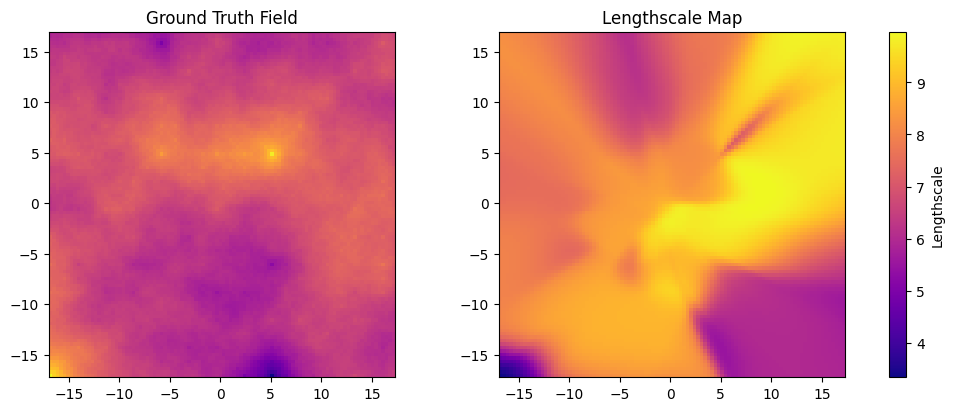

In [4]:
# Train GP to get optimized kernel parameters and lengthscales
_, noise_variance, kernel = get_model_params(
    X_train=X_train, y_train=y_train, 
    kernel=get_kernel('Attentive')(np.linspace(1, 10, 10)),
    optimizer='tf.Nadam',
    learning_rate=1e-2,
    max_steps=1000,
    verbose=True
)
ls_grid = kernel.get_lengthscales(X_grid)

# Plot Ground Truth vs. Lengthscales
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

sc1 = axes[0].imshow(y_grid.reshape(x_dim, y_dim).T,
                     extent=extent, origin="lower", cmap='plasma')
axes[0].set_title("Ground Truth Field")
axes[0].set_aspect('equal')

sc2 = axes[1].imshow(ls_grid.reshape(x_dim, y_dim).T, 
                     extent=extent, origin="lower", cmap='plasma')
axes[1].set_title("Lengthscale Map")
axes[1].set_aspect('equal')
fig.colorbar(sc2, ax=axes, orientation='vertical', label='Lengthscale')
plt.show()

## Establishing Baseline Uncertainty

Planning the IPP solution requires establishing a baseline GP:

**Initial Fit:** We use the pilot data `(X_init, y_init)` to train an initial GP with an Attentive kernel.

**Set the Target:** We evaluate the predictive variance across the environment and set a fraction of the maximum variance as our threshold.

**Optimize:** The IPP method plans a new path to collect sufficient data, guaranteeing the environment's uncertainty drops below our target requirement.

In [5]:
# Get the maximum prior variance to set our coverage target
_, _, _, init_model = get_model_params(
    X_train=X_init, y_train=y_init, 
    kernel=get_kernel('Attentive')(np.linspace(1, 10, 10)),
    optimizer='tf.Nadam', learning_rate=1e-2, max_steps=1000, return_model=True, verbose=False
)
max_prior_var = init_model.predict_f(X_grid)[1].numpy().max()
print(f"Max Prior Variance: {max_prior_var:.4f}")

Max Prior Variance: 0.5235


## Uncertainty-Guaranteed IPP (Standard Initialization)

We will now evaluate three Uncertainty-Guaranteed IPP methods:

* `HexCover`: Highly efficient but strictly limited to convex, stationary environments and RBF kernels. Does not support path-length constraints.
* `GreedyCover`: Fast; handles non-convex/non-stationary environments with any kernel. No path-length constraints.
* `GCBCover`: Slower but comprehensive; handles non-convex/non-stationary environments with any kernel and supports path-length constraints.

The objective for `GreedyCover` and `GCBCover` is to place sensors iteratively until the GP's posterior variance drops below a set threshold (e.g., 50% of the maximum prior variance).

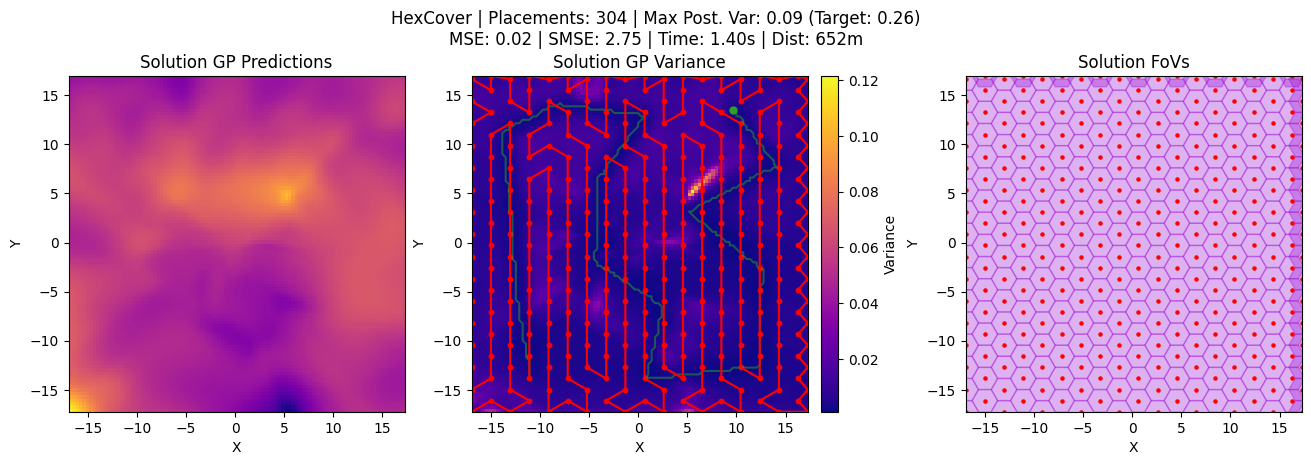

Failed to achieve target coverage. Retrying with increased slack ratio...
Failed to achieve target coverage. Retrying with increased slack ratio...
Failed to achieve target coverage. Retrying with increased slack ratio...


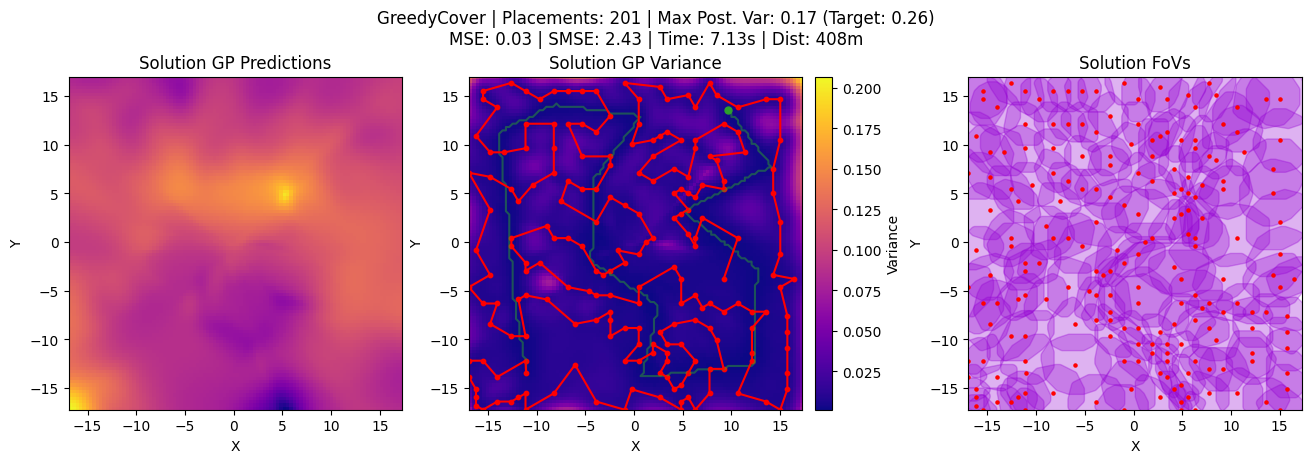

Failed to achieve target coverage. Retrying with increased slack ratio...
Failed to achieve target coverage. Retrying with increased slack ratio...
Failed to achieve target coverage. Retrying with increased slack ratio...


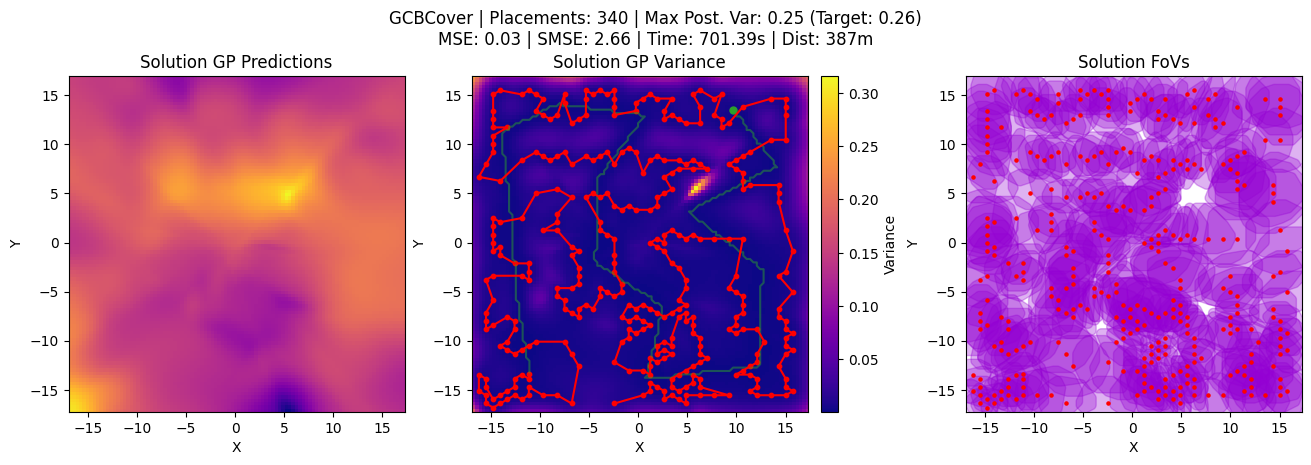

In [6]:
target_var_ratio = 0.5
var_threshold = max_prior_var * target_var_ratio
methods_to_test = ['HexCover', 'GreedyCover', 'GCBCover']
baseline_dist = float("inf")

for method in methods_to_test:
    if method == 'GCBCover':
        kwargs = {'distance_budget': baseline_dist * 0.95}
    else:
        kwargs = {}

    cmodel = get_method(method)(num_sensing=len(X_train),
                                X_objective=X_train,
                                kernel=kernel,
                                noise_variance=noise_variance)

    # Optimize placement
    s_time = time()
    X_sol, fovs = cmodel.optimize(post_var_threshold=var_threshold, 
                                  return_fovs=True,
                                  start_nodes=X_init[None, -1],
                                  **kwargs)
    X_sol = X_sol[0]
    run_time = time() - s_time

    # Evaluate the solution using the GP
    X_pred, y_pred = dataset.get_sensor_data(X_sol, max_samples=len(X_sol))
    _, _, _, model_sol = get_model_params(
        X_train=np.vstack([X_init, X_pred]), 
        y_train=np.vstack([y_init, y_pred]), 
        kernel=kernel, noise_variance=noise_variance,
        max_steps=0, return_model=True, verbose=False, force_gp=True
    )
    
    mean, var = model_sol.predict_f(X_grid)
    max_post_var = model_sol.predict_f(X_train)[1].numpy().max()
    
    # Calculate performance metrics
    distance = get_distance(X_sol)
    mse_e = get_mse(mean.numpy(), y_grid)
    smse_e = get_smse(mean.numpy(), y_grid, var.numpy())

    if method == 'GreedyCover':
        baseline_dist = distance

    title = (f"{method} | Placements: {len(fovs)} | Max Post. Var: {max_post_var:.2f} "
             f"(Target: {var_threshold:.2f})\nMSE: {mse_e:.2f} | SMSE: {smse_e:.2f} | "
             f"Time: {run_time:.2f}s | Dist: {distance:.0f}m")
    
    plot_coverage_results(mean.numpy(), var.numpy(), fovs, X_sol, X_init, title, extent, (x_dim, y_dim))

**Result Analysis**
* `HexCover`: Fastest, but limited to stationary, convex environments. It over-samples certain areas, resulting in unnecessary variance reduction, redundant measurements, and longer travel paths.

* `GreedyCover`: Fast and efficient; meets the target variance using fewer sensing locations and less travel distance.

* `GCBCover`: Slower to compute, but it successfully adheres to an explicit distance budget (set here to 98% of the `GreedyCover` path length).

**📝 Note: Target Coverage Retries**

If you see the message *"Failed to achieve target coverage. Retrying with increased slack ratio..."*, here is what is happening under the hood:

* **The Trigger**: `GreedyCover` and `GCBCover` select from a discrete set of candidate locations. If the initial set cannot satisfy your variance threshold, the algorithm intercepts the failure.

* **The Mechanism**: It automatically increases the "slack ratio," generating a denser pool of candidate locations, and restarts the optimization.

* **The Trade-off**: While this auto-retry is designed to save your run, multiple retries can slow down execution. If your target is too strict, it may ultimately still fail to find a valid solution.

## Uncertainty-Guaranteed IPP with Warm Start

Optimization often improves when seeded with a "warm start" of pilot path data. We will pass `X_init` to the `X_warm_start` parameter in `GreedyCover` and `GCBCover` to see how this prior path influences the resulting paths. 

*(Note: HexCover is purely geometric and does not support warm starts).*

Failed to achieve target coverage. Retrying with increased slack ratio...
Failed to achieve target coverage. Retrying with increased slack ratio...
Failed to achieve target coverage. Retrying with increased slack ratio...


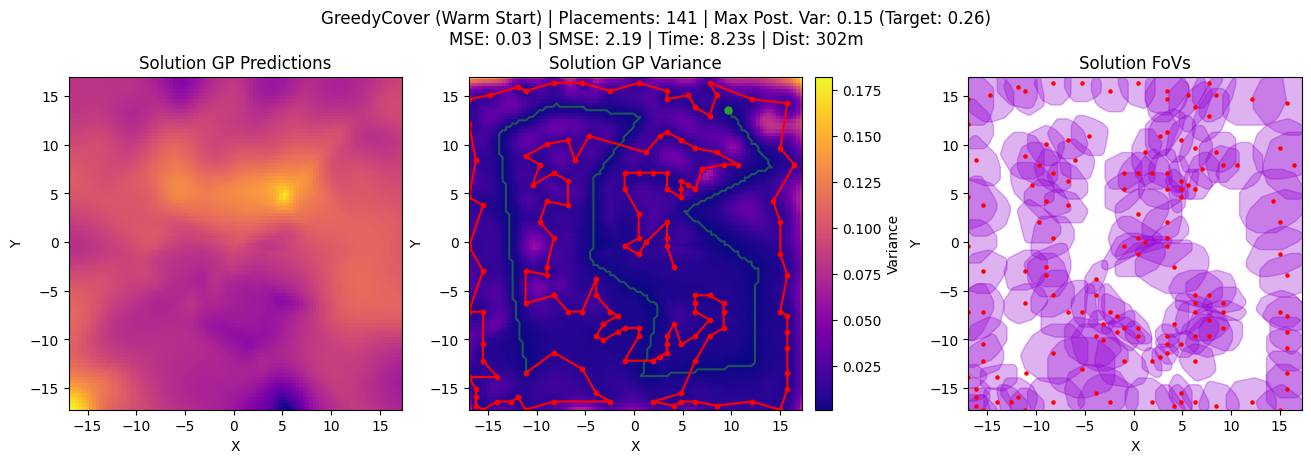

Failed to achieve target coverage. Retrying with increased slack ratio...
Failed to achieve target coverage. Retrying with increased slack ratio...
Failed to achieve target coverage. Retrying with increased slack ratio...


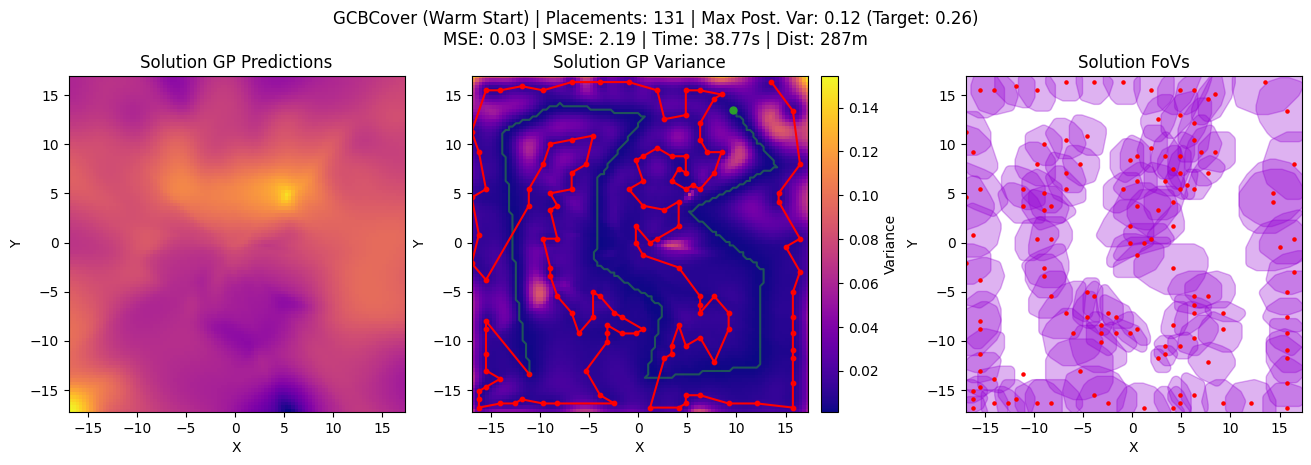

In [7]:
methods_to_test_warm = ['GreedyCover', 'GCBCover']
baseline_dist = float("inf")  # Reset baseline distance for warm start comparisons

for method in methods_to_test_warm:
    if method == 'GCBCover':
        kwargs = {'distance_budget': baseline_dist * 0.95}
    else:
        kwargs = {}

    cmodel = get_method(method)(num_sensing=len(X_train),
                                X_objective=X_train,
                                kernel=kernel,
                                noise_variance=noise_variance)

    # Optimize placement WITH warm start
    s_time = time()
    X_sol, fovs = cmodel.optimize(post_var_threshold=var_threshold, 
                                  return_fovs=True,
                                  X_warm_start=X_init,       # Injecting the warm start
                                  start_nodes=X_init[None, -1],
                                  **kwargs)
    X_sol = X_sol[0]
    run_time = time() - s_time

    # Evaluate the solution
    X_pred, y_pred = dataset.get_sensor_data(X_sol, max_samples=len(X_sol))
    _, _, _, model_sol = get_model_params(
        X_train=np.vstack([X_init, X_pred]), 
        y_train=np.vstack([y_init, y_pred]), 
        kernel=kernel, noise_variance=noise_variance,
        max_steps=0, return_model=True, verbose=False, force_gp=True
    )
    
    mean, var = model_sol.predict_f(X_grid)
    max_post_var = model_sol.predict_f(X_train)[1].numpy().max()
    
    distance = get_distance(X_sol)
    mse_e = get_mse(mean.numpy(), y_grid)
    smse_e = get_smse(mean.numpy(), y_grid, var.numpy())

    if method == 'GreedyCover':
        baseline_dist = distance

    title = (f"{method} (Warm Start) | Placements: {len(fovs)} | Max Post. Var: {max_post_var:.2f} "
             f"(Target: {var_threshold:.2f})\nMSE: {mse_e:.2f} | SMSE: {smse_e:.2f} | "
             f"Time: {run_time:.2f}s | Dist: {distance:.0f}m")
    
    plot_coverage_results(mean.numpy(), var.numpy(), fovs, X_sol, X_init, title, extent, (x_dim, y_dim))

**Result Analysis**

Notice that both methods avoid redundantly sampling the initial pilot path. This efficiency significantly reduces both the required measurements and the total travel distance.